# Custom Factor Sensor Fusion

This notebook introduces `gtsam.CustomFactor` with a simple 1D tracking problem. We estimate a car's position at five time steps and add three kinds of measurements one by one:

- GPS factors on individual states
- odometry factors between consecutive states
- relative measurements to known landmarks

The goal is not realism. The goal is to show, as clearly as possible, how a Python callback becomes a factor in a GTSAM graph.

GTSAM Copyright 2010-2019, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved

Authors: Fan Jiang, Frank Dellaert

See LICENSE for the license information

<a href="https://colab.research.google.com/github/borglab/gtsam/blob/develop/python/gtsam/examples/CustomFactorExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass

In [2]:
from functools import partial
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np

import gtsam

np.set_printoptions(precision=2, suppress=True)

## 1. Simulate a Simple 1D Trajectory

To keep the example focused on `CustomFactor`, each state is just a 1D vector containing the car's position.

In [3]:
def simulate_car() -> np.ndarray:
    """Simulate a car moving at constant speed for one second."""
    dt = 0.25  # 4 Hz, similar to a low-rate GPS.
    speed = 144 * 1000 / 3600  # 144 km/h = 40 m/s.
    return np.array([speed * dt * k for k in range(5)], dtype=float)


trajectory = simulate_car()
keys = [gtsam.symbol("x", k) for k in range(len(trajectory))]

print("Ground-truth positions:", trajectory)
print("Keys:", [gtsam.DefaultKeyFormatter(key) for key in keys])

Ground-truth positions: [ 0. 10. 20. 30. 40.]
Keys: ['x0', 'x1', 'x2', 'x3', 'x4']


## 2. Create Noisy Measurements

We use three sensor types. GPS measures absolute position, odometry measures motion between consecutive states, and the landmark sensor measures the car's position relative to a known landmark.

In [4]:
rng = np.random.default_rng(42)

sigma_gps = 3.0
sigma_odometry = 0.1
sigma_landmark = 1.0

gps_measurements = trajectory + rng.normal(0.0, sigma_gps, size=len(trajectory))
odometry_measurements = np.diff(trajectory) + rng.normal(0.0, sigma_odometry, size=len(trajectory) - 1)

landmark_positions = {0: 5.0, 3: 28.0}
landmark_measurements = {
    0: (trajectory[0] - landmark_positions[0]) + rng.normal(0.0, sigma_landmark),
    3: (trajectory[3] - landmark_positions[3]) + rng.normal(0.0, sigma_landmark),
}

gps_noise = gtsam.noiseModel.Isotropic.Sigma(1, sigma_gps)
odometry_noise = gtsam.noiseModel.Isotropic.Sigma(1, sigma_odometry)
landmark_noise = gtsam.noiseModel.Isotropic.Sigma(1, sigma_landmark)

print("GPS measurements:", gps_measurements)
print("Odometry measurements:", odometry_measurements)
print("Landmark-relative measurements:", landmark_measurements)

GPS measurements: [ 0.91415124  6.88004768 22.25135359 32.82169415 34.14689443]
Odometry measurements: [ 9.86978205 10.01278404  9.96837574  9.99831988]
Landmark-relative measurements: {0: np.float64(-5.85304392757358), 3: np.float64(2.8793979748628287)}


## 3. Define Custom Residual Callbacks

A Python `CustomFactor` callback always has the same shape:

```python
callback(this, values, jacobians) -> residual
```

When GTSAM asks for Jacobians, we write them into the `jacobians` list.

In [5]:
ID_1X1 = np.eye(1)


def error_gps(
    measurement: float,
    this: gtsam.CustomFactor,
    values: gtsam.Values,
    jacobians: Optional[list[np.ndarray]],
) -> np.ndarray:
    key = this.keys()[0]
    estimate = values.atVector(key)
    if jacobians is not None:
        jacobians[0] = ID_1X1
    return estimate - np.array([measurement])


def error_odometry(
    measurement: float,
    this: gtsam.CustomFactor,
    values: gtsam.Values,
    jacobians: Optional[list[np.ndarray]],
) -> np.ndarray:
    key1, key2 = this.keys()
    position1 = values.atVector(key1)
    position2 = values.atVector(key2)
    if jacobians is not None:
        jacobians[0] = -ID_1X1
        jacobians[1] = ID_1X1
    return (position2 - position1) - np.array([measurement])


def error_landmark(
    landmark_position: float,
    measurement: float,
    this: gtsam.CustomFactor,
    values: gtsam.Values,
    jacobians: Optional[list[np.ndarray]],
) -> np.ndarray:
    key = this.keys()[0]
    position = values.atVector(key)
    if jacobians is not None:
        jacobians[0] = ID_1X1
    return (position - landmark_position) - np.array([measurement])

## 4. Build and Solve Graphs

To make the comparison easy to read, we use a small helper that builds a factor graph with different sensor combinations.

In [ ]:
def make_initial_values() -> gtsam.Values:
    initial = gtsam.Values()
    for key in keys:
        initial.insert(key, np.array([0.0]))
    return initial


def optimize_graph(graph: gtsam.NonlinearFactorGraph) -> gtsam.Values:
    params = gtsam.GaussNewtonParams()
    return gtsam.GaussNewtonOptimizer(graph, make_initial_values(), params).optimize()


def build_graph(
    *, use_odometry: bool = False, use_landmarks: bool = False
) -> gtsam.NonlinearFactorGraph:
    graph = gtsam.NonlinearFactorGraph()

    # A GPS factor touches one state.
    for key, measurement in zip(keys, gps_measurements):
        graph.add(
            gtsam.CustomFactor(gps_noise, [key], partial(error_gps, float(measurement)))
        )

    # An odometry factor couples two consecutive states.
    if use_odometry:
        for key1, key2, measurement in zip(keys[:-1], keys[1:], odometry_measurements):
            graph.add(
                gtsam.CustomFactor(
                    odometry_noise,
                    [key1, key2],
                    partial(error_odometry, float(measurement)),
                )
            )

    # A landmark factor uses a known landmark position and a relative measurement.
    if use_landmarks:
        for index, landmark_position in landmark_positions.items():
            graph.add(
                gtsam.CustomFactor(
                    landmark_noise,
                    [keys[index]],
                    partial(
                        error_landmark,
                        float(landmark_position),
                        float(landmark_measurements[index]),
                    ),
                )
            )

    return graph


def result_array(result: gtsam.Values) -> np.ndarray:
    return np.array([result.atVector(key)[0] for key in keys])

## 5. Compare Three Sensor Suites

In [7]:
results = {}

for label, use_odometry, use_landmarks in [
    ("GPS only", False, False),
    ("GPS + odometry", True, False),
    ("GPS + odometry + landmarks", True, True),
]:
    graph = build_graph(use_odometry=use_odometry, use_landmarks=use_landmarks)
    result = optimize_graph(graph)
    estimate = result_array(result)
    results[label] = estimate
    print(f"{label:28s} {estimate}   graph error = {graph.error(result):.3f}")

GPS only                     [ 0.91415124  6.88004768 22.25135359 32.82169415 34.14689443]   graph error = 0.000
GPS + odometry               [-0.48523821  9.38298896 19.39699917 29.36342957 39.3559616 ]   graph error = 3.083
GPS + odometry + landmarks   [-0.04999492  9.82674634 19.84976371 29.82570434 39.8177233 ]   graph error = 4.030


## 6. Visualize the Improvement

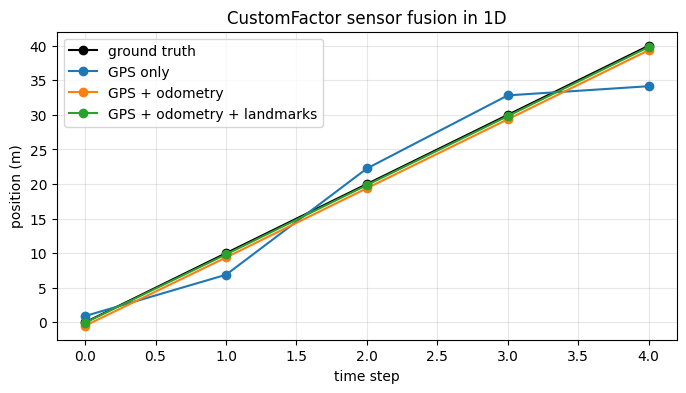

In [8]:
time = np.arange(len(trajectory))

plt.figure(figsize=(8, 4))
plt.plot(time, trajectory, "k-o", label="ground truth")
for label, estimate in results.items():
    plt.plot(time, estimate, marker="o", label=label)

plt.xlabel("time step")
plt.ylabel("position (m)")
plt.title("CustomFactor sensor fusion in 1D")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Takeaways

- `CustomFactor` lets you describe a factor by writing just a residual callback.
- The callback can capture measurements and any other constants it needs.
- Once the callback is wrapped in a factor, the rest of the workflow is standard GTSAM: build a graph, initialize variables, and optimize.